<a href="https://colab.research.google.com/github/janacor/Programacion/blob/main/Duncan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -r requirements.txt
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Duncan_csv.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, accountant to waiter
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   type       45 non-null     object
 1   income     45 non-null     int64 
 2   education  45 non-null     int64 
 3   prestige   45 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.8+ KB


<Figure size 1200x800 with 0 Axes>

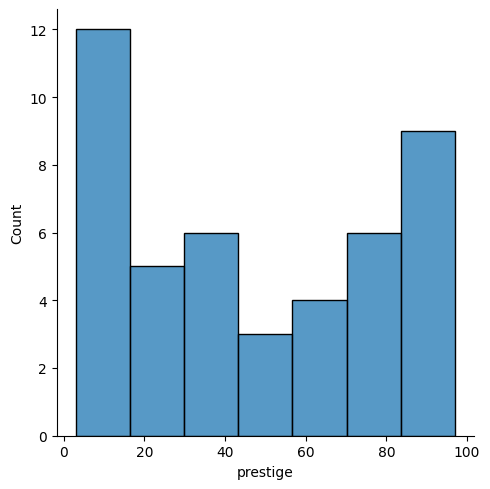

In [3]:
# Aplicar One-Hot Encoding a la columna 'type'
df_encoded = pd.get_dummies(df, columns=['type'])
df_encoded = df_encoded.astype(int)  # convierte True/False a 1/0 si es necesario
plt.figure(figsize=(12, 8))
sns.displot(df_encoded['prestige'])

In [4]:
df_encoded.corr()['prestige'].sort_values()

,prestige
type_bc,-0.748343
type_wc,-0.138752
income,0.837801
education,0.851916
type_prof,0.858354
prestige,1.000000


Las variables que más se correlacionan positivamente con el prestigio son:

* **type_prof (+0.86)**
* **education (+0.85)**
* **income (+0.84)**

La categoría type_bc (blue collar) tiene una fuerte correlación negativa con el prestigio: normalmente estas ocupaciones tienen menos prestigio.

type_wc (white collar) no muestra una correlación fuerte ni positiva ni negativa.

<Axes: xlabel='income', ylabel='prestige'>

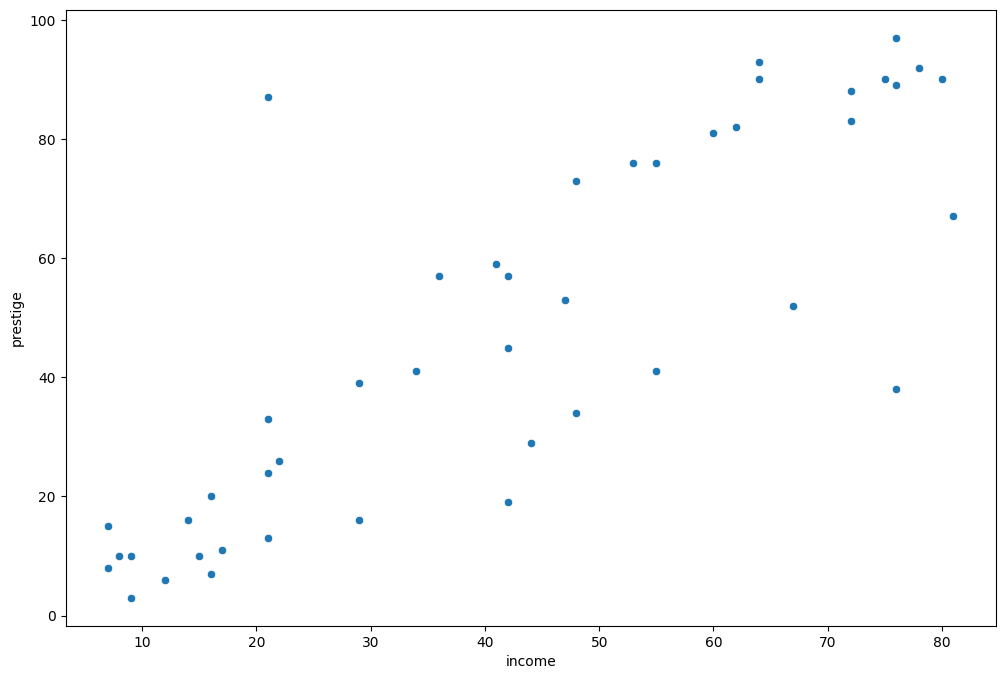

In [5]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='income', y='prestige', data=df_encoded)

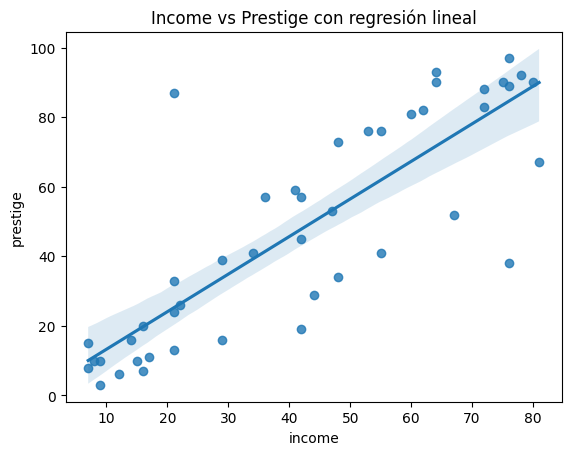

In [6]:
sns.regplot(data=df_encoded, x='income', y='prestige')
plt.title('Income vs Prestige con regresión lineal')
plt.show()

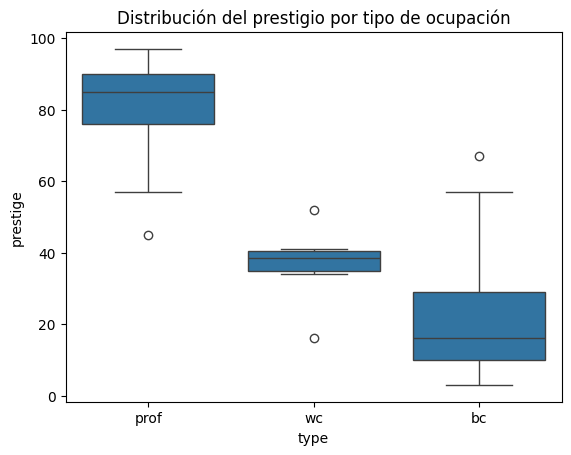

In [7]:
sns.boxplot(data=df, x='type', y='prestige')
plt.title('Distribución del prestigio por tipo de ocupación')
plt.show()

MAE Regresión lineal:  7.706954042169018


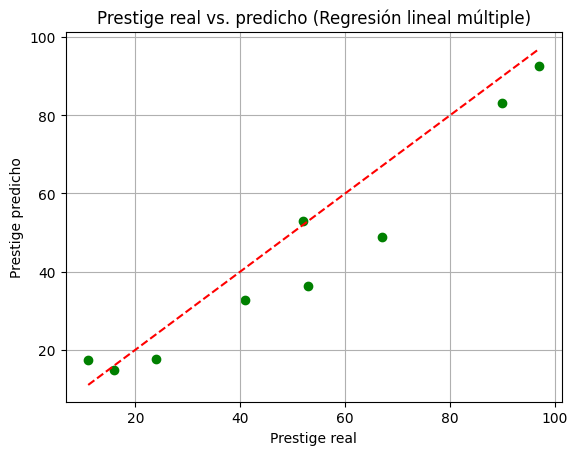

MSE en conjunto de prueba: 92.35107560461068
RMSE en conjunto de prueba: 9.609946701444846


In [24]:
# Realizar el entrenamiento
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

x = df_encoded.drop('prestige', axis=1) #todas las variables menos la variable dependiente
y = df_encoded['prestige'] # variable dependiente ; la que queremos predecir

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model_linear = LinearRegression().fit(x_train, y_train)
y_test_pred = model_linear.predict(x_test)
mae_linear = mean_absolute_error(y_test, y_test_pred)
print("MAE Regresión lineal: ", mae_linear)

# Gráfico: y real vs y predicho
y_pred = model_linear.predict(x_test)
plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Prestige real')
plt.ylabel('Prestige predicho')
plt.title('Prestige real vs. predicho (Regresión lineal múltiple)')
plt.grid(True)
plt.show()
mse_linear = mean_squared_error(y_test, y_test_pred)
print("MSE en conjunto de prueba:", mse_linear)
rmse_linear = np.sqrt(mse_linear)
print("RMSE en conjunto de prueba:", rmse_linear)

In [13]:
x_train

,income,education,type_bc,type_prof,type_wc
author,55,90,0,1,0
professor,64,93,0,1,0
carpenter,21,23,1,0,0
streetcar.motorman,42,26,1,0,0
banker,78,82,0,1,0
factory.owner,60,56,0,1,0
welfare.worker,41,84,0,1,0
janitor,7,20,1,0,0
conductor,76,34,0,0,1
engineer,72,86,0,1,0
